# 03. Modeling & Đánh giá: Telco Customer Churn

So sánh nhiều mô hình dự đoán churn, chọn ra mô hình tốt nhất, và xác định ngưỡng dự đoán
tối ưu dựa trên chi phí thực tế: chi phí mất khách hàng so với chi phí ưu đãi giữ chân.

## 0. Mục tiêu notebook

- Tìm mô hình dự đoán churn tốt nhất trong nhiều lựa chọn, dựa vào con số cao
  nhất và kiểm tra xem chênh lệch đó có đáng tin hay là nhiễu.
- Xây ma trận chi phí dựa trên giả định kinh doanh (chi phí mất khách so với chi phí ưu
  đãi giữ chân), từ đó chọn ngưỡng dự đoán giúp tiết kiệm nhiều chi phí nhất.
- Lưu lại mô hình và ngưỡng đã chọn, dùng cho bước giải thích mô hình tiếp theo.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import roc_curve, confusion_matrix, classification_report
from scipy.stats import loguniform, randint
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import features as fe
import evaluation as ev

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models'

## 1. Dữ liệu

Dùng lại tập train/validation/test đã chia ở bước xử lý dữ liệu trước. Test set chỉ được
dùng đúng 1 lần, ở bước đánh giá cuối cùng, để đảm bảo con số cuối cùng đáng tin cậy.

In [2]:
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv').set_index('customerID')
val_df = pd.read_csv(f'{PROCESSED_DIR}/val.csv').set_index('customerID')
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv').set_index('customerID')

X_train, y_train = train_df.drop(columns='Churn'), train_df['Churn']
X_val, y_val = val_df.drop(columns='Churn'), val_df['Churn']
X_test, y_test = test_df.drop(columns='Churn'), test_df['Churn']

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    'Cột giữa các tập dữ liệu không khớp!'

print('Train        :', X_train.shape, '| churn rate:', round(y_train.mean(), 4))
print('Validation   :', X_val.shape, '| churn rate:', round(y_val.mean(), 4))
print('Test         :', X_test.shape, '| churn rate:', round(y_test.mean(), 4))

Train        : (4225, 29) | churn rate: 0.2653
Validation   : (1409, 29) | churn rate: 0.2654
Test         : (1409, 29) | churn rate: 0.2654


## 2. So sánh các mô hình

Thử 4 loại mô hình (Logistic Regression, Random Forest, XGBoost, LightGBM), mỗi mô hình
đều được tinh chỉnh, kết hợp với 2 cách xử lý mất cân bằng dữ
liệu churn/không churn.

Logistic Regression cho phép chọn cách phạt hệ số đơn giản hơn (giữ ít biến hơn) hoặc đầy
đủ hơn. Cách đơn giản hơn vô tình xoá mất ảnh hưởng của cước hàng tháng và tổng cước đã
trả trong mô hình, hai yếu tố quan trọng khi giải thích cho khách hàng thực tế, trong khi
hiệu năng giữa 2 cách gần như không khác biệt. Vì vậy chọn cách giữ đầy đủ các biến.

Mọi tổ hợp đều được đánh giá trên tập validation để chọn ra tổ hợp tốt nhất. Test set
chưa chạm tới ở bước này.

In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight (tỷ lệ neg/pos trên train gốc):', round(scale_pos_weight, 3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cat_feature_idx = fe.get_categorical_feature_indices(X_train)


def build_pipeline(clf, variant, needs_scaling):
    steps = []
    if variant == 'SMOTENC':
        steps.append(('smote', SMOTENC(categorical_features=cat_feature_idx, random_state=RANDOM_STATE)))
    if needs_scaling:
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', clf))
    return ImbPipeline(steps)


search_specs = {
    'Logistic Regression': dict(
        clf=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, solver='liblinear'),
        needs_scaling=True,
        param_distributions={'clf__C': loguniform(1e-2, 1e2)},
        n_iter=20,
    ),
    'Random Forest': dict(
        clf=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
        needs_scaling=False,
        param_distributions={
            'clf__n_estimators': randint(150, 600),
            'clf__max_depth': [None, 6, 10, 14, 20],
            'clf__min_samples_leaf': randint(1, 10),
            'clf__max_features': ['sqrt', 'log2', None],
        },
        n_iter=20,
    ),
    'XGBoost': dict(
        clf=XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=1),
        needs_scaling=False,
        param_distributions={
            'clf__max_depth': randint(2, 9),
            'clf__learning_rate': loguniform(0.01, 0.3),
            'clf__n_estimators': randint(150, 600),
            'clf__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
            'clf__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
            'clf__reg_alpha': [0, 0.01, 0.1, 1],
            'clf__reg_lambda': [0.5, 1, 1.5, 2],
        },
        n_iter=25,
    ),
    'LightGBM': dict(
        clf=LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
        needs_scaling=False,
        param_distributions={
            'clf__num_leaves': randint(15, 128),
            'clf__learning_rate': loguniform(0.01, 0.3),
            'clf__n_estimators': randint(150, 600),
            'clf__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
            'clf__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
            'clf__reg_alpha': [0, 0.01, 0.1, 1],
            'clf__reg_lambda': [0, 0.5, 1, 1.5],
        },
        n_iter=25,
    ),
}

variants = [('class_weight', X_train, y_train), ('SMOTENC', X_train, y_train)]

fitted = {}
cv_scores = {}
for model_name, spec in search_specs.items():
    for variant, X_tr, y_tr in variants:
        is_cw = variant == 'class_weight'
        clf = clone(spec['clf'])
        if is_cw:
            if model_name in ('Logistic Regression', 'Random Forest'):
                clf.set_params(class_weight='balanced')
            elif model_name == 'XGBoost':
                clf.set_params(scale_pos_weight=scale_pos_weight)
            elif model_name == 'LightGBM':
                clf.set_params(class_weight='balanced')
        pipe = build_pipeline(clf, variant, spec['needs_scaling'])

        search = RandomizedSearchCV(
            pipe, spec['param_distributions'],
            n_iter=spec['n_iter'], scoring='roc_auc', cv=cv,
            random_state=RANDOM_STATE, n_jobs=-1, refit=True,
        )
        search.fit(X_tr, y_tr)

        key = (model_name, variant, str(search.best_params_))
        fitted[key] = search.best_estimator_
        cv_scores[key] = search.best_score_

results = []
for (model_name, variant, params_str), model in fitted.items():
    y_proba_val = model.predict_proba(X_val)[:, 1]
    metrics = ev.evaluate_predictions(y_val, y_proba_val, threshold=0.5)
    metrics['model'] = model_name
    metrics['data_variant'] = variant
    metrics['hyperparams'] = params_str
    metrics['cv_roc_auc_train'] = cv_scores[(model_name, variant, params_str)]
    results.append(metrics)

results_df = pd.DataFrame(results)[
    ['model', 'data_variant', 'hyperparams', 'cv_roc_auc_train', 'roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'accuracy']
].sort_values('roc_auc', ascending=False).reset_index(drop=True)

print(f'Đã tune {len(fitted)} tổ hợp (model x phương án) bằng RandomizedSearchCV '
      f'(5-fold CV, scoring=roc_auc, trên TRAIN set), đánh giá trên VALIDATION set:')
results_df.round(4).head(10)


scale_pos_weight (tỷ lệ neg/pos trên train gốc): 2.769


Đã tune 8 tổ hợp (model x phương án) bằng RandomizedSearchCV (5-fold CV, scoring=roc_auc, trên TRAIN set), đánh giá trên VALIDATION set:


,model,data_variant,hyperparams,cv_roc_auc_train,roc_auc,pr_auc,precision,recall,f1,accuracy
0,XGBoost,class_weight,"{'clf__colsample_bytree': 0.7, 'clf__learning_...",0.8504,0.8408,0.6503,0.5000,0.8128,0.6191,0.7346
1,Logistic Regression,class_weight,{'clf__C': np.float64(21.368329072358772)},0.8502,0.8396,0.6537,0.5106,0.7701,0.6141,0.7431
2,LightGBM,class_weight,"{'clf__colsample_bytree': 0.7, 'clf__learning_...",0.8450,0.8391,0.6436,0.5196,0.7807,0.6239,0.7502
3,Random Forest,class_weight,"{'clf__max_depth': 6, 'clf__max_features': 'lo...",0.8470,0.8384,0.6424,0.5147,0.7968,0.6254,0.7466
4,LightGBM,SMOTENC,"{'clf__colsample_bytree': 0.7, 'clf__learning_...",0.8415,0.8354,0.6179,0.5972,0.6898,0.6402,0.7942
5,XGBoost,SMOTENC,"{'clf__colsample_bytree': 0.7, 'clf__learning_...",0.8451,0.8349,0.6314,0.5358,0.7406,0.6218,0.7608
6,Random Forest,SMOTENC,"{'clf__max_depth': 6, 'clf__max_features': 'lo...",0.8437,0.8344,0.6148,0.5511,0.7353,0.6300,0.7708
7,Logistic Regression,SMOTENC,{'clf__C': np.float64(0.012087541473056965)},0.8404,0.8310,0.6304,0.5468,0.7032,0.6152,0.7665


In [4]:
top_row = results_df.iloc[0]
n_pos_val, n_neg_val = int((y_val == 1).sum()), int((y_val == 0).sum())
auc_se = ev.hanley_mcneil_se(top_row['roc_auc'], n_pos_val, n_neg_val)

print('Top 3 theo ROC-AUC (validation):')
display(results_df[['model', 'data_variant', 'roc_auc']].head(3).round(4))
print(f"Hanley-McNeil SE(AUC) ước lượng (n_pos={n_pos_val}, n_neg={n_neg_val}): {auc_se:.4f}")

# Nếu model xếp hạng #1 chỉ hơn Logistic Regression tốt nhất trong khoảng < 1 SE, chênh
# lệch đó không đủ ý nghĩa thống kê để đánh đổi lấy độ phức tạp/chi phí giải thích cao hơn
# (SHAP TreeExplainer, mất tính diễn giải trực tiếp qua hệ số hồi quy) — ưu tiên model đơn
# giản hơn khi 2 lựa chọn không thể phân biệt được bằng dữ liệu hiện có.
lr_rows = results_df[results_df['model'] == 'Logistic Regression'].sort_values('roc_auc', ascending=False)
best_lr_row = lr_rows.iloc[0]
gap = top_row['roc_auc'] - best_lr_row['roc_auc']

if top_row['model'] != 'Logistic Regression' and gap < auc_se:
    print(f"\nChênh lệch ROC-AUC giữa top-1 ({top_row['model']}, {top_row['roc_auc']:.4f}) và "
          f"Logistic Regression ({best_lr_row['roc_auc']:.4f}) = {gap:.4f}, nhỏ hơn 1 SE "
          f"({auc_se:.4f}) -> không đủ ý nghĩa thống kê để kết luận {top_row['model']} tốt "
          f"hơn thực sự. Giữ Logistic Regression làm model cuối (đơn giản hơn, diễn giải "
          f"trực tiếp qua hệ số hồi quy, không cần SHAP TreeExplainer).")
    best_row = best_lr_row
else:
    print(f"\nChênh lệch ROC-AUC giữa top-1 và Logistic Regression = {gap:.4f}, "
          f">= 1 SE ({auc_se:.4f}) -> đủ căn cứ chọn {top_row['model']} làm model cuối.")
    best_row = top_row

best_key = (best_row['model'], best_row['data_variant'], best_row['hyperparams'])
best_model = fitted[best_key]
best_proba_val = best_model.predict_proba(X_val)[:, 1]

print(f"\nModel cuối được chọn: {best_key[0]} ({best_key[1]}, hyperparams={best_key[2]}) "
      f"-> ROC-AUC (validation) = {best_row['roc_auc']:.4f}")

Top 3 theo ROC-AUC (validation):


,model,data_variant,roc_auc
0,XGBoost,class_weight,0.8408
1,Logistic Regression,class_weight,0.8396
2,LightGBM,class_weight,0.8391


Hanley-McNeil SE(AUC) ước lượng (n_pos=374, n_neg=1035): 0.0135

Chênh lệch ROC-AUC giữa top-1 (XGBoost, 0.8408) và Logistic Regression (0.8396) = 0.0012, nhỏ hơn 1 SE (0.0135) -> không đủ ý nghĩa thống kê để kết luận XGBoost tốt hơn thực sự. Giữ Logistic Regression làm model cuối (đơn giản hơn, diễn giải trực tiếp qua hệ số hồi quy, không cần SHAP TreeExplainer).

Model cuối được chọn: Logistic Regression (class_weight, hyperparams={'clf__C': np.float64(21.368329072358772)}) -> ROC-AUC (validation) = 0.8396


**Nhận xét nhanh:** bảng xếp hạng dựa trên điểm đo trên tập validation, chưa chạm tới test
set. 

Precision/Recall ở đây tính ở ngưỡng mặc định, chưa phải ngưỡng cuối cùng (chọn ở
mục 5).

## 3. Đường ROC của 4 mô hình

So sánh khả năng phân tách khách hàng churn/không churn của từng mô hình, với cấu hình
tốt nhất của mỗi mô hình.

Tổ hợp tốt nhất mỗi họ model (theo ROC-AUC validation):


,model,data_variant,hyperparams,roc_auc
0,LightGBM,class_weight,"{'clf__colsample_bytree': 0.7, 'clf__learning_...",0.8391
1,Logistic Regression,class_weight,{'clf__C': np.float64(21.368329072358772)},0.8396
2,Random Forest,class_weight,"{'clf__max_depth': 6, 'clf__max_features': 'lo...",0.8384
3,XGBoost,class_weight,"{'clf__colsample_bytree': 0.7, 'clf__learning_...",0.8408


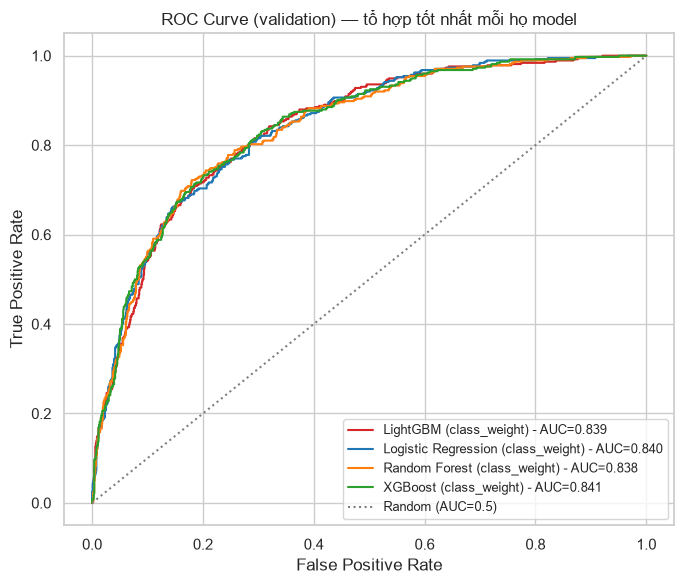

In [5]:
best_per_family = (
    results_df.sort_values('roc_auc', ascending=False)
    .groupby('model', as_index=False)
    .first()
)
print('Tổ hợp tốt nhất mỗi họ model (theo ROC-AUC validation):')
display(best_per_family[['model', 'data_variant', 'hyperparams', 'roc_auc']].round(4))

fig, ax = plt.subplots(figsize=(7, 6))
palette = dict(zip(['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
                    sns.color_palette('tab10', 4)))

for _, row in best_per_family.iterrows():
    key = (row['model'], row['data_variant'], row['hyperparams'])
    model = fitted[key]
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    ax.plot(fpr, tpr, color=palette[row['model']],
            label=f"{row['model']} ({row['data_variant']}) - AUC={row['roc_auc']:.3f}")

ax.plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (validation) — tổ hợp tốt nhất mỗi họ model')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/model_roc_comparison.png', dpi=150)
plt.show()

## 4. Yếu tố ảnh hưởng nhiều nhất đến churn

Đối chiếu với phân tích dữ liệu ban đầu: 
- Kỳ vọng loại hợp đồng, loại dịch vụ Internet, và
thời gian gắn bó đứng đầu danh sách ảnh hưởng
- Còn giới tính gần như không ảnh hưởng.

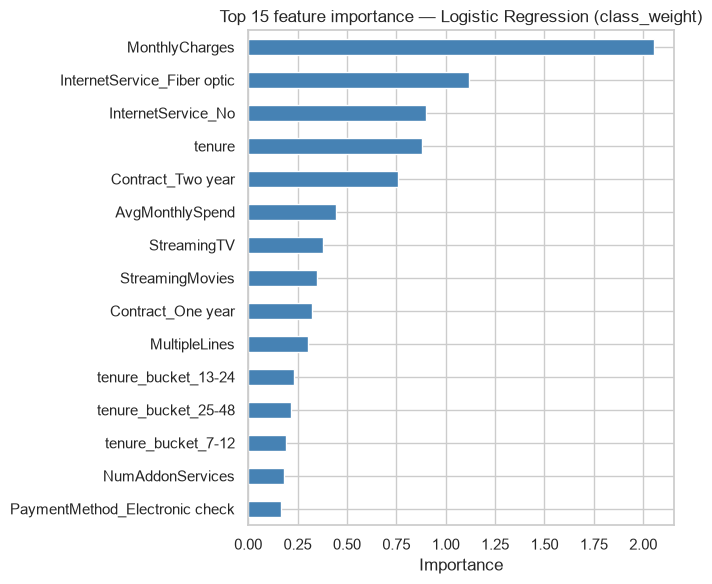

Hạng của gender: 26 / 29
Hạng của PhoneService: 16 / 29


In [6]:
importance = ev.get_feature_importance(best_model, X_val.columns)
top_n = 15

fig, ax = plt.subplots(figsize=(7, 6))
importance.head(top_n).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top {top_n} feature importance — {best_key[0]} ({best_key[1]})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

print('Hạng của gender:', list(importance.index).index('gender') + 1, '/', len(importance))
print('Hạng của PhoneService:', list(importance.index).index('PhoneService') + 1, '/', len(importance))

## 5. Ma trận chi phí và ngưỡng dự đoán tối ưu

**Giả định kinh doanh:**
- Bỏ sót 1 khách sắp rời bỏ (không phát hiện được) tốn khoảng 12 tháng cước của khách đó,
  tương đương doanh thu mất đi trong 1 năm.
- Can thiệp nhầm vào 1 khách vốn không định rời bỏ tốn 1 tháng cước ưu đãi.
- Chi phí tính riêng theo cước hàng tháng thực tế của từng khách, vì khách cước cao thiệt
  hại nhiều hơn khi rời bỏ.

Ngưỡng được chọn trên tập validation, test set chỉ dùng để xác nhận kết quả ở mục 6.

In [7]:
RETENTION_MONTHS_LOST = 12   # số tháng doanh thu mất nếu bỏ sót khách sẽ churn
RETENTION_OFFER_MONTHS = 1   # số tháng ưu đãi miễn phí khi can thiệp (đúng hoặc nhầm)

fn_cost_val = RETENTION_MONTHS_LOST * val_df['MonthlyCharges']
fp_cost_val = RETENTION_OFFER_MONTHS * val_df['MonthlyCharges']

best_threshold, cost_sweep_df = ev.best_threshold_by_cost(y_val, best_proba_val, fn_cost_val, fp_cost_val)
cost_at_default = ev.expected_cost(y_val, best_proba_val, 0.5, fn_cost_val, fp_cost_val)
cost_at_best = ev.expected_cost(y_val, best_proba_val, best_threshold, fn_cost_val, fp_cost_val)
cost_no_model = fn_cost_val[y_val == 1].sum()  # baseline: không can thiệp ai cả

print('(Kết quả trên VALIDATION set — dùng để CHỌN threshold, chưa phải kết quả cuối)')
print(f'Threshold mặc định (0.5)   -> chi phí: ${cost_at_default:,.0f}')
print(f'Threshold tối ưu ({best_threshold:.2f}) -> chi phí: ${cost_at_best:,.0f}')
print(f'Baseline không có model    -> chi phí: ${cost_no_model:,.0f}')
print()
print(f'Tiết kiệm so với không có model : ${cost_no_model - cost_at_best:,.0f} '
      f'({(cost_no_model - cost_at_best) / cost_no_model:.1%})')
print(f'Tiết kiệm so với threshold 0.5   : ${cost_at_default - cost_at_best:,.0f} '
      f'({(cost_at_default - cost_at_best) / cost_at_default:.1%})')

(Kết quả trên VALIDATION set — dùng để CHỌN threshold, chưa phải kết quả cuối)
Threshold mặc định (0.5)   -> chi phí: $88,378
Threshold tối ưu (0.15) -> chi phí: $48,587
Baseline không có model    -> chi phí: $340,259

Tiết kiệm so với không có model : $291,671 (85.7%)
Tiết kiệm so với threshold 0.5   : $39,791 (45.0%)


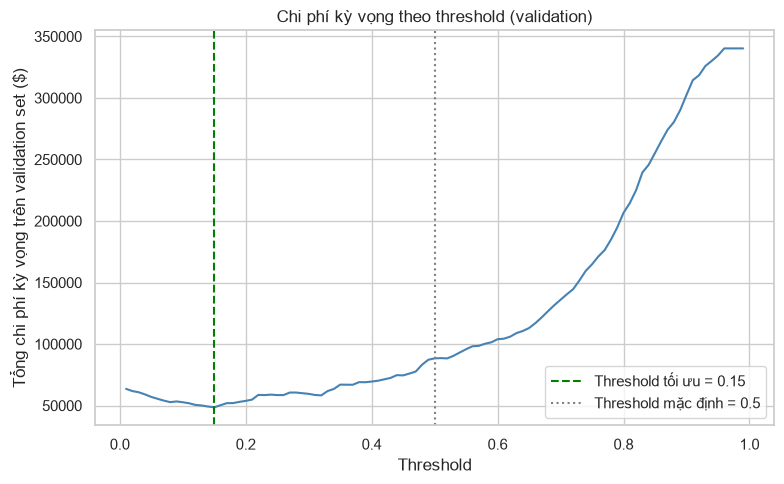

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_sweep_df['threshold'], cost_sweep_df['total_cost'], color='steelblue')
ax.axvline(best_threshold, color='green', linestyle='--',
           label=f'Threshold tối ưu = {best_threshold:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', label='Threshold mặc định = 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('Tổng chi phí kỳ vọng trên validation set ($)')
ax.set_title('Chi phí kỳ vọng theo threshold (validation)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/cost_vs_threshold.png', dpi=150)
plt.show()

### 5b. Giả định chi phí có làm thay đổi kết luận không?

Con số 12 tháng ở mục 5 là giả định, không phải sự thật tuyệt đối. Phần này kiểm tra: nếu
giả định đó thay đổi, ngưỡng tối ưu và mức tiết kiệm có còn giữ nguyên kết luận không, hay
chỉ đúng vừa khít với con số 12 được chọn.

In [9]:
RETENTION_OFFER_MONTHS_FIXED = 1  # giữ cố định khi quét — chi phí ưu đãi là số biết chắc
months_lost_grid = [3, 6, 9, 12, 15, 18, 24, 36]

sensitivity_rows = []
for months_lost in months_lost_grid:
    fn_cost_sens = months_lost * val_df['MonthlyCharges']
    fp_cost_sens = RETENTION_OFFER_MONTHS_FIXED * val_df['MonthlyCharges']

    thr_sens, _ = ev.best_threshold_by_cost(y_val, best_proba_val, fn_cost_sens, fp_cost_sens)
    cost_no_model_sens = fn_cost_sens[y_val == 1].sum()
    cost_default_sens = ev.expected_cost(y_val, best_proba_val, 0.5, fn_cost_sens, fp_cost_sens)
    cost_best_sens = ev.expected_cost(y_val, best_proba_val, thr_sens, fn_cost_sens, fp_cost_sens)

    sensitivity_rows.append({
        'months_lost:offer': f'{months_lost}:1',
        'best_threshold': thr_sens,
        'savings_vs_no_model_pct': (cost_no_model_sens - cost_best_sens) / cost_no_model_sens,
        'savings_vs_default_pct': (cost_default_sens - cost_best_sens) / cost_default_sens,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print('Sensitivity analysis (validation set) — threshold tối ưu & % tiết kiệm theo giả định chi phí FN:')
display(sensitivity_df.round(4))

Sensitivity analysis (validation set) — threshold tối ưu & % tiết kiệm theo giả định chi phí FN:


,months_lost:offer,best_threshold,savings_vs_no_model_pct,savings_vs_default_pct
0,3:1,0.47,0.5726,0.0407
1,6:1,0.32,0.7351,0.1764
2,9:1,0.15,0.8152,0.3410
3,12:1,0.15,0.8572,0.4502
4,15:1,0.15,0.8824,0.5245
5,18:1,0.15,0.8992,0.5783
6,24:1,0.15,0.9202,0.6510
7,36:1,0.08,0.9452,0.7492


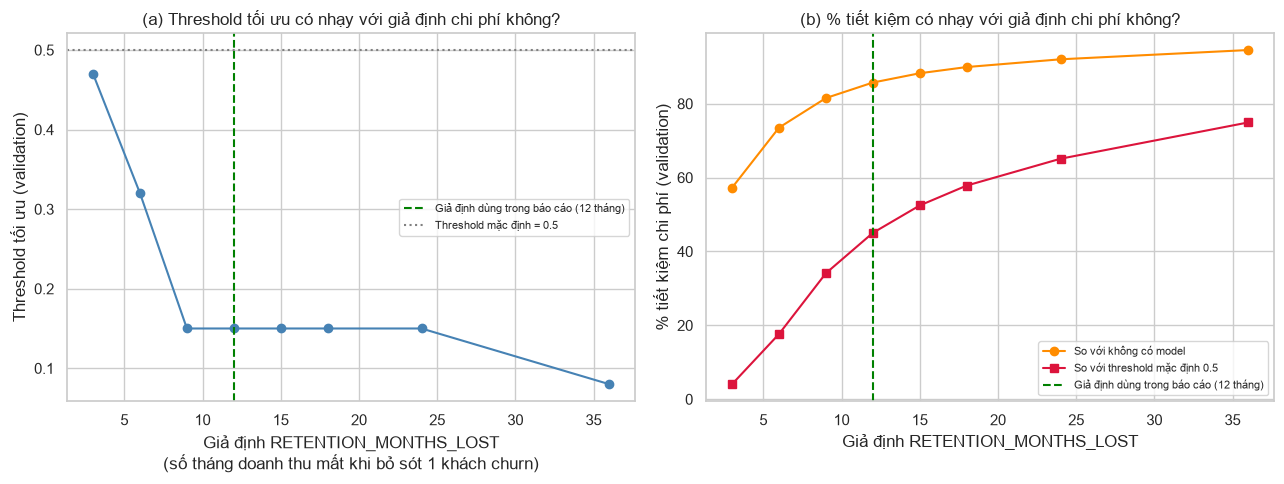

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(months_lost_grid, sensitivity_df['best_threshold'], marker='o', color='steelblue')
axes[0].axvline(RETENTION_MONTHS_LOST, color='green', linestyle='--',
                label=f'Giả định dùng trong báo cáo ({RETENTION_MONTHS_LOST} tháng)')
axes[0].axhline(0.5, color='grey', linestyle=':', label='Threshold mặc định = 0.5')
axes[0].set_xlabel('Giả định RETENTION_MONTHS_LOST\n(số tháng doanh thu mất khi bỏ sót 1 khách churn)')
axes[0].set_ylabel('Threshold tối ưu (validation)')
axes[0].set_title('(a) Threshold tối ưu có nhạy với giả định chi phí không?')
axes[0].legend(fontsize=8)

axes[1].plot(months_lost_grid, sensitivity_df['savings_vs_no_model_pct'] * 100,
             marker='o', color='darkorange', label='So với không có model')
axes[1].plot(months_lost_grid, sensitivity_df['savings_vs_default_pct'] * 100,
             marker='s', color='crimson', label='So với threshold mặc định 0.5')
axes[1].axvline(RETENTION_MONTHS_LOST, color='green', linestyle='--',
                label=f'Giả định dùng trong báo cáo ({RETENTION_MONTHS_LOST} tháng)')
axes[1].set_xlabel('Giả định RETENTION_MONTHS_LOST')
axes[1].set_ylabel('% tiết kiệm chi phí (validation)')
axes[1].set_title('(b) % tiết kiệm có nhạy với giả định chi phí không?')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/cost_sensitivity_analysis.png', dpi=150)
plt.show()

**Kết luận:**

- Ngưỡng tối ưu giữ nguyên ở 0,15 trong khoảng tỷ lệ chi phí khá rộng (9:1 đến 24:1), bao
  gồm cả giả định gốc 12:1. Ở 2 đầu khảo sát, ngưỡng lệch nhiều hơn: 0,47 khi tỷ lệ chi
  phí thấp (3:1) và 0,08 khi tỷ lệ chi phí cao (36:1).
- Dù giả định thay đổi thế nào trong khoảng khảo sát, kết luận "nên đặt ngưỡng thấp hơn
  nhiều so với mặc định 0,5" vẫn đúng, và luôn tiết kiệm được chi phí đáng kể so với không
  dùng mô hình (57%-95%).
- Riêng con số tiết kiệm cụ thể (35,9% trong báo cáo) nhạy hơn với giả định, dao động từ
  4% đến 75% tuỳ tỷ lệ chi phí. Nên hiểu đây là một khoảng ước tính, không phải con số cố
  định.

## 6. Kết quả trên tập test 

Mô hình, ngưỡng, và mọi lựa chọn đều đã chốt từ trước dựa trên tập validation. Tập test
chỉ dùng đúng 1 lần ở đây để xác nhận kết quả cuối cùng.

In [11]:
best_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_final = (best_proba_test >= best_threshold).astype(int)
final_metrics = ev.evaluate_predictions(y_test, best_proba_test, threshold=best_threshold)

fn_cost_test = RETENTION_MONTHS_LOST * test_df['MonthlyCharges']
fp_cost_test = RETENTION_OFFER_MONTHS * test_df['MonthlyCharges']
cost_test_default = ev.expected_cost(y_test, best_proba_test, 0.5, fn_cost_test, fp_cost_test)
cost_test_best = ev.expected_cost(y_test, best_proba_test, best_threshold, fn_cost_test, fp_cost_test)
cost_test_no_model = fn_cost_test[y_test == 1].sum()

print(f"Model cuối: {best_key[0]} ({best_key[1]}, hyperparams={best_key[2]})")
print(f"Threshold (chọn từ validation): {best_threshold:.2f}")
print()
print('--- Metrics trên TEST SET ---')
for k, v in final_metrics.items():
    print(f'  {k}: {v:.4f}')
print()
print(f'Chi phí ở threshold {best_threshold:.2f} : ${cost_test_best:,.0f}')
print(f'Chi phí ở threshold 0.5 (mặc định) : ${cost_test_default:,.0f}')
print(f'Chi phí không có model             : ${cost_test_no_model:,.0f}')
print()
print(f'Tiết kiệm so với không có model : {(cost_test_no_model - cost_test_best) / cost_test_no_model:.1%}')
print(f'Tiết kiệm so với threshold 0.5   : {(cost_test_default - cost_test_best) / cost_test_default:.1%}')
print()
print(classification_report(y_test, y_pred_final, target_names=['No churn', 'Churn']))

Model cuối: Logistic Regression (class_weight, hyperparams={'clf__C': np.float64(21.368329072358772)})
Threshold (chọn từ validation): 0.15

--- Metrics trên TEST SET ---
  roc_auc: 0.8452
  pr_auc: 0.6518
  precision: 0.3759
  recall: 0.9759
  f1: 0.5428
  accuracy: 0.5635

Chi phí ở threshold 0.15 : $49,993
Chi phí ở threshold 0.5 (mặc định) : $78,034
Chi phí không có model             : $326,579

Tiết kiệm so với không có model : 84.7%
Tiết kiệm so với threshold 0.5   : 35.9%

              precision    recall  f1-score   support

    No churn       0.98      0.41      0.58      1035
       Churn       0.38      0.98      0.54       374

    accuracy                           0.56      1409
   macro avg       0.68      0.70      0.56      1409
weighted avg       0.82      0.56      0.57      1409



**Nhận xét:** mô hình bắt được 97,6% khách hàng thực sự sẽ churn (recall), nhưng trong số
khách bị gắn cờ rủi ro chỉ khoảng 37,6% là đúng thực sự sắp rời bỏ (precision), tức cứ
khoảng 2,7 khách được liên hệ thì có 1 khách đúng. Accuracy tổng thể chỉ 56%, đây là đánh
đổi có chủ đích của ngưỡng 0,15: ưu tiên bắt được nhiều khách sắp churn nhất, vì bỏ sót 1
khách churn thật tốn kém hơn nhiều so với chăm sóc nhầm 1 khách. Thước đo đúng ở đây là
chi phí thực tế: dùng mô hình tiết kiệm 84,7% so với không can thiệp, và 35,9% so với
ngưỡng mặc định 0,5.

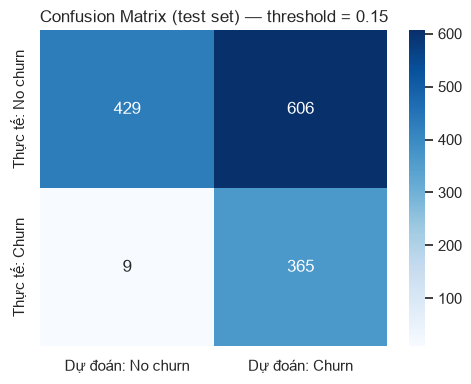

In [12]:
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dự đoán: No churn', 'Dự đoán: Churn'],
            yticklabels=['Thực tế: No churn', 'Thực tế: Churn'])
ax.set_title(f'Confusion Matrix (test set) — threshold = {best_threshold:.2f}')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_final.png', dpi=150)
plt.show()

## 7. Lưu lại mô hình và ngưỡng đã chọn

In [13]:
model_artifact = {
    'model': best_model,
    'model_name': best_key[0],
    'data_variant': best_key[1],
    'hyperparams': best_key[2],
    'threshold': best_threshold,
    'feature_columns': list(X_test.columns),
    'val_roc_auc': float(best_row['roc_auc']),
    'test_roc_auc': float(final_metrics['roc_auc']),
    'test_precision': float(final_metrics['precision']),
    'test_recall': float(final_metrics['recall']),
    'cost_assumptions': {
        'retention_months_lost': RETENTION_MONTHS_LOST,
        'retention_offer_months': RETENTION_OFFER_MONTHS,
    },
}
joblib.dump(model_artifact, f'{MODELS_DIR}/best_model.joblib')
print(f'Đã lưu {MODELS_DIR}/best_model.joblib')
print(f"Model: {model_artifact['model_name']} ({model_artifact['data_variant']}, "
      f"{model_artifact['hyperparams']}), threshold={model_artifact['threshold']:.2f}")
print(f"Validation ROC-AUC={model_artifact['val_roc_auc']:.4f} | "
      f"Test ROC-AUC={model_artifact['test_roc_auc']:.4f}")

Đã lưu ../models/best_model.joblib
Model: Logistic Regression (class_weight, {'clf__C': np.float64(21.368329072358772)}), threshold=0.15
Validation ROC-AUC=0.8396 | Test ROC-AUC=0.8452


## 8. Tóm tắt Note

- So sánh 8 tổ hợp (4 mô hình x 2 cách xử lý mất cân bằng dữ liệu). Không có cách xử lý
  nào thắng tuyệt đối, kết quả khá sát nhau tuỳ mô hình.
- Mô hình có điểm cao nhất (XGBoost) chỉ nhỉnh hơn Logistic Regression một chút (0,8408
  so với 0,8396), mức chênh lệch này không đủ tin cậy để kết luận XGBoost thực sự tốt
  hơn. Chọn Logistic Regression vì đơn giản, nhanh và dễ giải thích.
- Yếu tố ảnh hưởng nhiều nhất khớp với phân tích dữ liệu ban đầu: giới tính và việc có
  dùng dịch vụ điện thoại hay không gần như không ảnh hưởng đến churn.
- Với giả định bỏ sót 1 khách churn tốn 12 tháng cước, còn can thiệp nhầm tốn 1 tháng ưu
  đãi: ngưỡng dự đoán tối ưu là 0,15 (thay vì mặc định 0,5), tiết kiệm được 85,7% chi phí
  so với không dùng mô hình, và 45% so với dùng ngưỡng mặc định (đo trên validation).
- Kiểm tra độ nhạy cho thấy kết luận này vẫn vững nếu giả định chi phí thay đổi trong
  khoảng khá rộng, chỉ riêng con số tiết kiệm cụ thể là dao động theo giả định.
- Trên tập test (chạm đúng 1 lần): ROC-AUC 0,8452, tiết kiệm 84,7% chi phí so với không
  dùng mô hình, 35,9% so với ngưỡng mặc định. Mô hình bắt được 97,6% khách sẽ churn, đổi
  lại có khá nhiều cảnh báo nhầm.

**Giới hạn:**
- Kết quả dựa trên 1 lần dữ liệu train/val/test cố định.
- Giả định chi phí (12 tháng doanh thu mất/1 tháng ưu đãi) là đơn giản hoá, chưa tính giá
  trị vòng đời khách hàng hay chi phí vận hành thực tế khi triển khai.

**Tiếp theo:** dùng SHAP để giải thích mô hình đã chọn, xác định nhóm khách hàng rủi
ro cao, và đề xuất chiến lược giữ chân theo phân khúc.